In [1]:
import numpy as np
import scipy.stats
from scipy import stats
from scipy.stats import norm
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit

In [2]:
mu = 0
ligma = 0.5
N = 1000
D = 1000

In [ ]:
integr = np.array([])
var = np.array([])
x = np.linspace(1,D,D)

for i in range (D):
    var = np.append(var, 0)

#definisco la pdf (gaussiana) con cui voglio estrarre i dati
distG = scipy.stats.norm(loc =mu , scale=ligma)

#Creo l'array Draws, formato da i+1 estrazioni, calcolo montecarlo per i+1 estrazioni
#calcolo la varianza del mio risultato, ripeto D volte
for i in range (D):
    draws = np.absolute(distG.rvs(i+1))
    integr = np.append(integr, ((2*3.14)**0.5)*ligma*np.mean((draws)**3)/2)
    var[i] = np.var(integr)

plt.scatter(x,integr,s=5)
plt.show()

result = 2 * ligma**4
result,integr[D-1]   

In [4]:
#definisco il modello con cui interpolare

def model_f(x,k):
    return k/(x**0.5);

array([0.02094173])

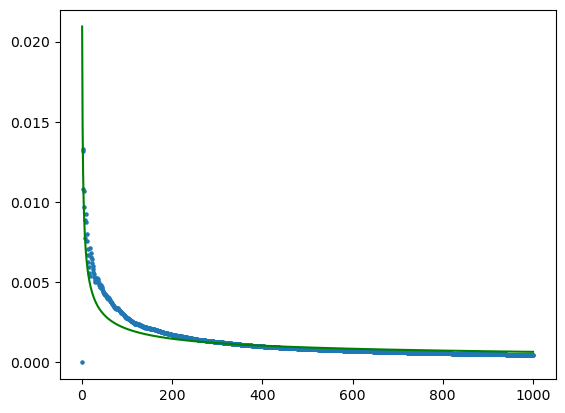

In [5]:
#interpolo con 1/sqrt(x), 
popt, pcov = curve_fit(model_f, x, var, p0 =(1))
k_opt = popt
y_var = model_f(x, k_opt)

plt.plot(x,y_var, color='g')
plt.scatter(x,var,s=5)
popt

Now i calculate how are the results distributed


(array([ 4.,  0., 11., 13., 12., 25.,  9., 12.,  6.,  8.]),
 array([0.06539544, 0.07616492, 0.08693439, 0.09770387, 0.10847334,
        0.11924282, 0.13001229, 0.14078177, 0.15155125, 0.16232072,
        0.1730902 ]),
 <BarContainer object of 10 artists>)

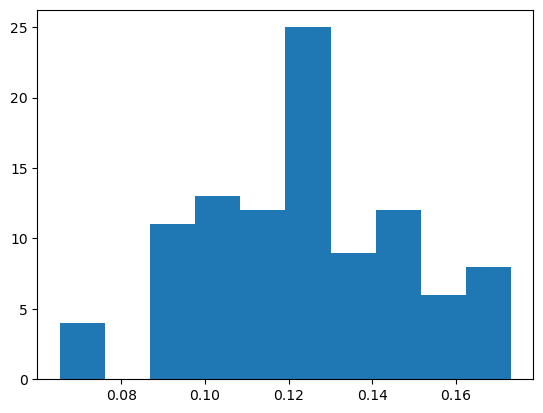

In [7]:
#define a low N distribution
N_low = 100
low_value = np.array([])

for i in range (N_low):
    low_value = np.append(low_value, 0)

#riempio l'array di risultati dell'integrale con N basso 
for i in range(N_low):
    draws_low = np.absolute(distG.rvs(N_low))
    low_value[i] = ((2*3.14)**0.5)*ligma*np.mean((draws_low)**3)/2

plt.hist(low_value)

(array([  14.,  239., 1296., 3994., 6137., 5225., 2390.,  605.,   88.,
          12.]),
 array([0.1174406 , 0.1190293 , 0.120618  , 0.1222067 , 0.1237954 ,
        0.12538409, 0.12697279, 0.12856149, 0.13015019, 0.13173889,
        0.13332759]),
 <BarContainer object of 10 artists>)

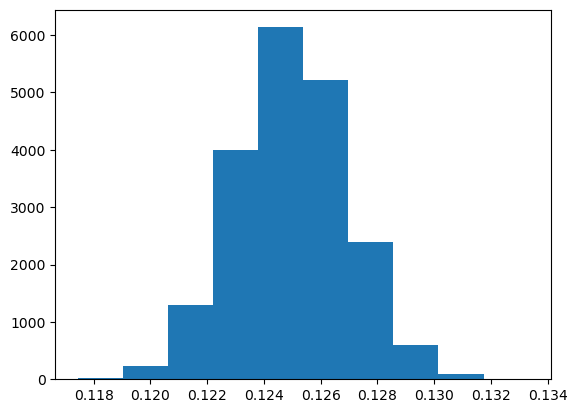

In [10]:
#define a high N distribution
N_high = 20000

high_value = np.array([])

for i in range (N_high):
    high_value = np.append(high_value, 0)

#riempio l'array di risultati dell'integrale con N alto 
for i in range(N_high):
    draws_high = np.absolute(distG.rvs(N_high))
    high_value[i] = ((2*3.14)**0.5)*ligma*np.mean((draws_high)**3)/2

plt.hist(high_value)